# 02 — Моделювання затоплення
Порівняння простого порогу та алгоритму зв'язаності для різних сценаріїв рівня моря.

In [1]:
import sys, pathlib
import matplotlib.pyplot as plt
import numpy as np

project_root = pathlib.Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.loader import load_dem
from src.model import FloodModel
from src.gis_utils import flood_area_km2


In [2]:
processed_path = pathlib.Path('../data/raw/OSNOVA.tif')
fallback_raw = pathlib.Path('../data/raw/Suvorov.tif')
path_to_use = processed_path if processed_path.exists() else fallback_raw

dem, profile, bounds = load_dem(str(path_to_use))
model = FloodModel(dem)
print("Кількість < 0:", np.sum(dem < 0)) ## пікселі нижче рівня моря

Кількість < 0: 9670


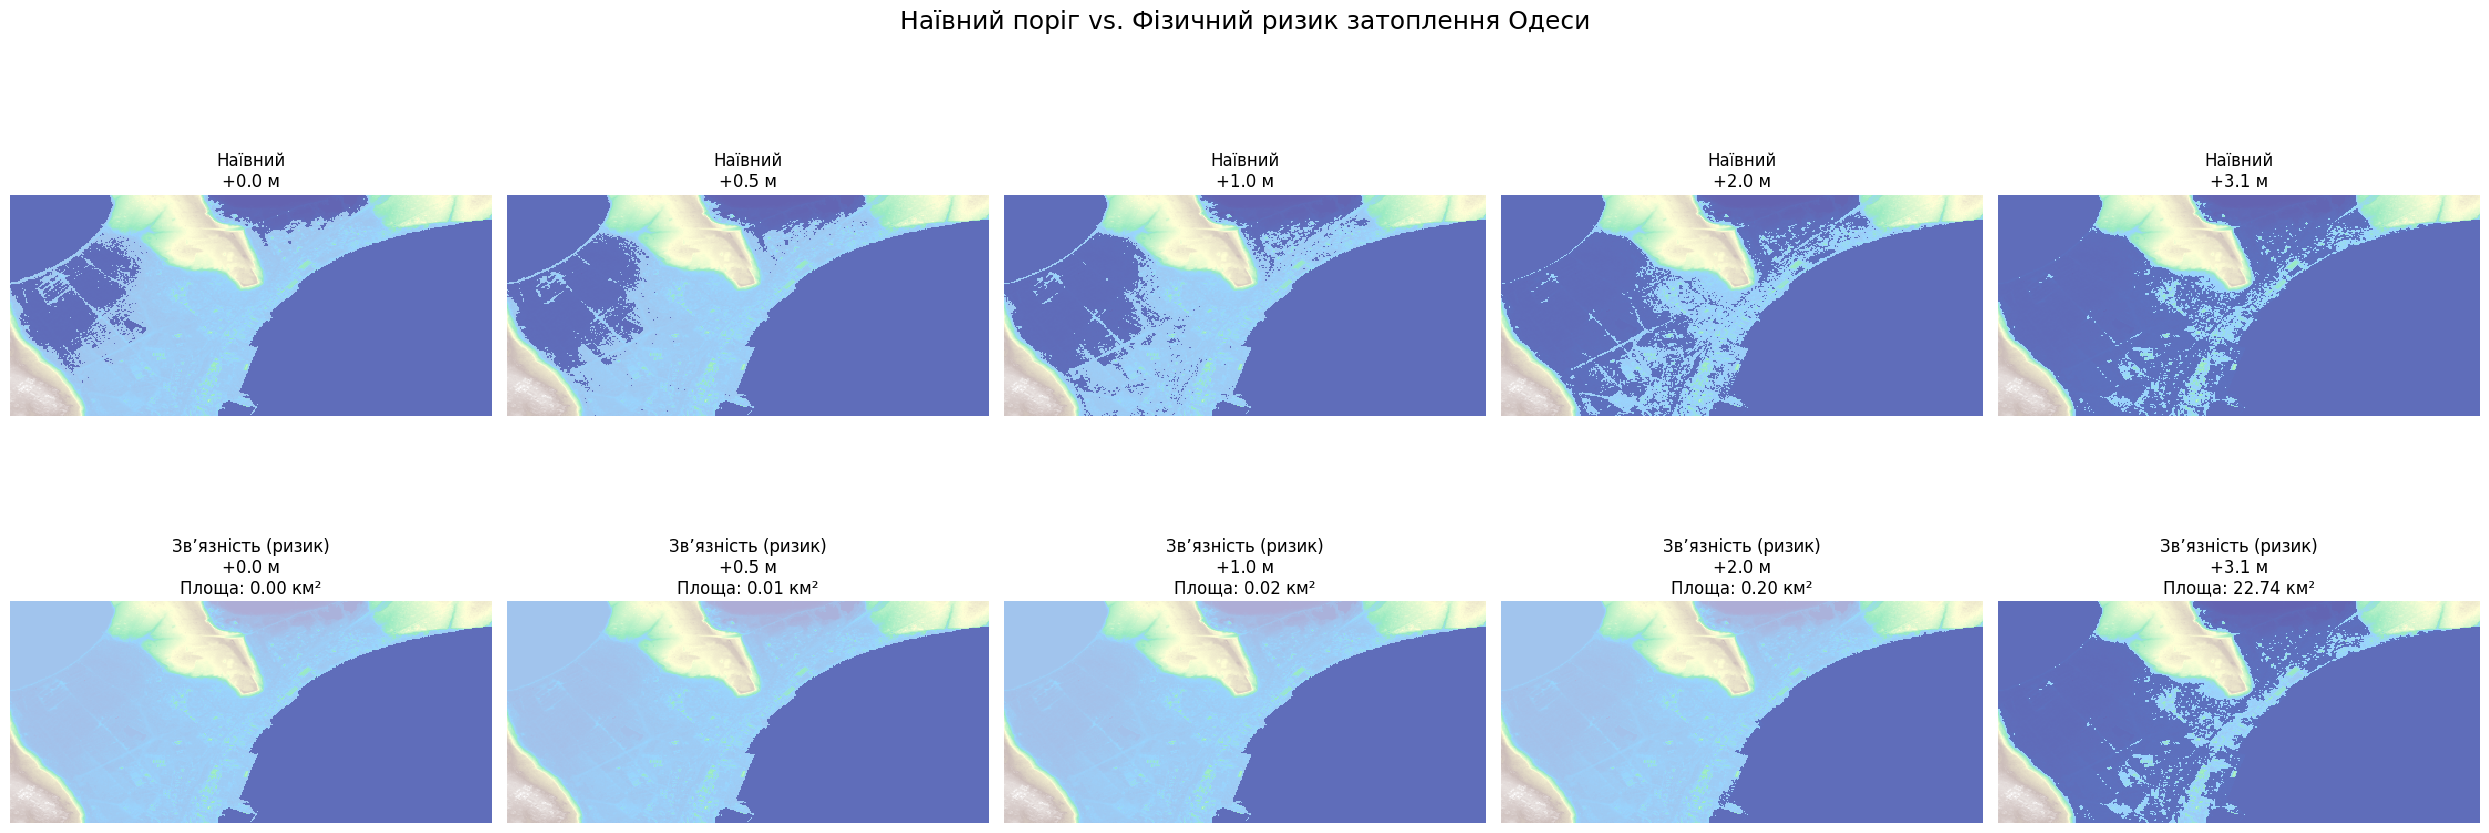

In [3]:
sea_bias = 0.0
flood_now = model.calculate_flood(sea_bias)

scenarios = [0.0, 0.5, 1.0, 2.0, 3.1]
fig, axes = plt.subplots(2, len(scenarios), figsize=(5 * len(scenarios), 10)) 
fig.suptitle("Наївний поріг vs. Фізичний ризик затоплення Одеси", fontsize=18)

for j, H in enumerate(scenarios): # оримуємо індекс сценарію та його відповідне підняття рівня моря H
    level = sea_bias + H 

    naive = model.simple_threshold(level) 
    flood_H = model.calculate_flood(level)

    masks = [naive, flood_H]

    for i, mask in enumerate(masks):
        ax = axes[i, j]

        ax.imshow(dem, cmap="terrain", alpha=0.4, interpolation='nearest')

        flooded_visual = np.ma.masked_where(~mask, mask) # Створюємо маску для візуалізації затоплених областей (True - затоплено, False - не затоплено)
        ax.imshow(flooded_visual, cmap="terrain", alpha=0.6, interpolation='nearest')

        if i == 1:
            risk = flood_H & (~flood_now) & (dem < level) 
            area_km2 = flood_area_km2(risk, profile, bounds)
            title = f"Зв’язність (ризик)\n+{H} м\nПлоща: {area_km2:.2f} км²"
        else:
            title = f"Наївний\n+{H} м"

        ax.set_title(title)
        ax.axis("off")

plt.tight_layout()
plt.show()


In [4]:
H = 2.0
sea_bias = 0.0

flood_mask = model.calculate_flood(sea_bias + H)
new_flood  = flood_mask & (~model.calculate_flood(sea_bias))

print("ЗАГАЛЬНЕ затоплення (flood_mask):", flood_mask.sum())
print("ТІЛЬКИ нові пікселі (new_flood):", new_flood.sum())


ЗАГАЛЬНЕ затоплення (flood_mask): 32178
ТІЛЬКИ нові пікселі (new_flood): 310


In [5]:
from rasterio.features import shapes
from shapely.geometry import shape
import geopandas as gpd
import numpy as np

H_EXPORT = 0.1 # рівень підняття моря для експорту карти ризику
sea_bias = 0.0 # базове море рівень
level = sea_bias + H_EXPORT

# Повінь при +H
flood_mask = model.calculate_flood(level)

# Базове море при 0
base_mask = model.calculate_flood(sea_bias)

# Ново-затоплена суша
new_flood = flood_mask & (~base_mask)

# Глибина тільки для ново-затопленої суші
depth_new = np.full_like(dem, np.nan, dtype=float)
depth_new[new_flood] = level - dem[new_flood]

# Векторизація
features = []
for geom, value in shapes(
        depth_new,
        mask=~np.isnan(depth_new),
        transform=profile["transform"]
    ):
    features.append({
        "geometry": shape(geom),
        "depth_m": round(float(value), 2)
    })

gdf = gpd.GeoDataFrame(features, crs=profile["crs"])

OUT_FILE = f"flood_RISK_{H_EXPORT:.1f}m.geojson"
gdf.to_file(OUT_FILE, driver="GeoJSON")

print(f"   Експортовано карту ризику для суші: {OUT_FILE}")
print(f"   Ново-затоплених пікселів: {int(new_flood.sum()):,}")
print(f"   Площа ризику: {flood_area_km2(new_flood, profile, bounds):.2f} км²")


   Експортовано карту ризику для суші: flood_RISK_0.1m.geojson
   Ново-затоплених пікселів: 4
   Площа ризику: 0.00 км²
